# Network Layers
- Feature Extraction: extract the features based on the given price tensor. They can be LSTM or RNN or CNN
- Feature Analysis:
- Network Improvement:


In [ ]:
import tensorflow as tf
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from typing import Tuple, List, Optional

In [ ]:
class FeatureExtractor(tf.keras.Model):
    def __init__(self, hidden=64):
        super().__init__()
        self.lstm = tf.keras.layers.LSTM(hidden, return_sequences=False)

    def call(self, Y_t):
       # Suppose Y_t is (columns/features, assets, timeframe/window):
        C = tf.shape(Y_t)[0] #channels/features
        A = tf.shape(Y_t)[1] # assets involved
        W = tf.shape(Y_t)[2] # time embedding

        x = tf.reshape(Y_t, [C*A, W ])   # (time=W, features=A*C)
        z = self.lstm(x)
        return z


In [ ]:
class FeatureAnalyzer(tf.keras.Model):
    def __init__(self, hidden=64):
        super().__init__()
        # get the right input size and output sizes for the layers
        self.mlp = tf.keras.layers.Sequential([
            tf.keras.layers.Dense(hidden, activation="relu"),
            tf.keras.layers.Dense(hidden, activation="relu"),
            tf.keras.layers.Dense(1, activation=None),
        ])
    def call(self, FE_t, price_pred, S_p_price_ratio, w_prev):
    # concatenating the output from FE to price _prediction and S&P price ratio
        x = tf.concat([FE_t, price_pred,w_prev, S_p_price_ratio], axis=-1)
        z = self.mlp(x)
        return z


In [ ]:
import tensorflow as tf

def soft_update(target_model, source_model, tau=0.005):
    for t, s in zip(target_model.trainable_variables, source_model.trainable_variables):
        t.assign(tau * s + (1.0 - tau) * t)

def bcm_log_loss(a_bar, mu_pred, eps=1e-7):
    #binary log-loss
    mu_pred = tf.clip_by_value(mu_pred, eps, 1.0 - eps)
    loss = -(a_bar * tf.math.log(mu_pred) + (1.0 - a_bar) * tf.math.log(1.0 - mu_pred))
    return tf.reduce_mean(loss)

# @tf.function
def ni_train_step(
    actor, critic,
    actor_target, critic_target,
    actor_opt, critic_opt,
    batch,
    gamma=0.99,
    tau=0.005,
    lambda_bc=0.01,
    policy_delay=2
):
    # --- step counter for policy_delay ---
    if not hasattr(ni_train_step, "step"):
        ni_train_step.step = 0
    ni_train_step.step += 1

    # Unpack batch
    if isinstance(batch, dict):
        s    = batch["s"]
        a    = batch["a"]
        r    = batch["r"]
        s2   = batch["s2"]
        done = batch["done"]
        a_bar= batch.get("a_bar", None)
    else:
        s, a, r, s2, done, a_bar = batch

    # 1) Critic update (ALWAYS)
    with tf.GradientTape() as tape:
        a2 = actor_target(s2, training=False)
        q2 = critic_target(s2, a2, training=False)
        y  = r + gamma * (1.0 - done) * q2
        q  = critic(s, a, training=True)
        critic_loss = tf.reduce_mean(tf.square(q - tf.stop_gradient(y)))

    critic_grads = tape.gradient(critic_loss, critic.trainable_variables)
    critic_opt.apply_gradients(zip(critic_grads, critic.trainable_variables))

    # Defaults if we skip actor update this step
    actor_loss = tf.constant(0.0)
    bc_loss    = tf.constant(0.0)

    # 2) Actor update (ONLY every policy_delay steps)
    if (ni_train_step.step % policy_delay) == 0:
        with tf.GradientTape() as tape:
            a_pred = actor(s, training=True)
            q_pred = critic(s, a_pred, training=False)
            pg_loss = -tf.reduce_mean(q_pred)

            if (lambda_bc > 0.0) and (a_bar is not None):
                bc_loss = bcm_log_loss(a_bar, a_pred)
                actor_loss = pg_loss + lambda_bc * bc_loss
            else:
                actor_loss = pg_loss

        actor_grads = tape.gradient(actor_loss, actor.trainable_variables)
        actor_opt.apply_gradients(zip(actor_grads, actor.trainable_variables))

        # 3) Soft update targets (usually tied to actor update)
        soft_update(actor_target, actor, tau=tau)
        soft_update(critic_target, critic, tau=tau)

    return critic_loss, actor_loss, bc_loss

In [ ]:
class ActorHead(tf.keras.Model):
    def __init__(self, n_assets, hidden=(128, 64)):
        super().__init__()
        self.mlp = tf.keras.Sequential([
            tf.keras.layers.Dense(hidden[0], activation="relu"),
            tf.keras.layers.Dense(hidden[1], activation="relu"),
            tf.keras.layers.Dense(n_assets, activation=None),
        ])
    # actor takes in the observations and returns the actions
    # maximizing long term returns
    def call(self, h):
        logits = self.mlp(h)
        w = tf.nn.softmax(logits, axis=-1)   # (B, n_assets)
        return w


In [ ]:
class CriticHead(tf.keras.Model):
    def __init__(self, hidden=(128, 64)):
        super().__init__()
        self.mlp = tf.keras.Sequential([
            tf.keras.layers.Dense(hidden[0], activation="relu"),
            tf.keras.layers.Dense(hidden[1], activation="relu"),
            tf.keras.layers.Dense(1, activation=None),
        ])
    # The critic takes in the actions and state observed and returns the
    # expectation of the long-term reward
    def call(self, h, a):
        x = tf.concat([h, a], axis=-1)
        q = self.mlp(x)
        return q


# Infusion Prediction Module
The input is the tensor of the close, high, low and percentage price change for each asset at each timestep

In [ ]:
# Non linear Dynamic Boltzmann
import tensorflow as tf
class LSTM_IPM(tf.keras.Model):
  def __init__(self, D, hidden=64, dropout = 0.5):
    super().__init__()
    self.lstm = tf.keras.layers.LSTM(hidden, return_sequences=False)
    self.drop = tf.keras.layers.Dropout(dropout)
    self.out = tf.keras.layers.Dense(D)
  def call(self, x_seq, training = False):
    # x_seq : (B,W,D) D is the feature dimension: number of assets times number
    # of features
    h = self.lstm(x_seq, training = training)
    h = self.drop(h, training = training)
    mu = self.out(h)
    return mu



In [ ]:
# The online update module
import numpy as np
from collections import deque
class OnlineLSTMIPM:
  def __init__(self, D , W = 24, lr = 1e-3, hidden = 128):
    self.D = D
    self.W = W
    self.lr = lr
    # W is the window
    self.buf = deque([np.zeros(D, dtype = np.float32) for _ in range(W)], maxlen = W)
    self.model = LSTM_IPM(D, hidden)
    self.optimizer = tf.keras.optimizers.Adam(learning_rate = lr)
    self.loss_fn = tf.keras.losses.MeanSquaredError()

    # create a dummy model
    dummy = tf.zeros((1,W,D))
    _ = self.model(dummy)

    def predict(self):
      x_seq = np.stack(self.buf, axis = 0)[None, ...]
      mu = self.model(tf.convert_to_tensor(x_seq), training = False)
      return mu.numpy()[0]

    def update(self, x_t):
      # Using the previous W steps
      x_t  = np.asarray(x_t, dtype = np.float32)
      x_seq = np.stack(self.buf, axis = 0)[None, ...]
      y_true = x_t[None, ...] # converts the data into a batch
      with tf.GradientTape() as tape:
          y_pred = self.model(tf.convert_to_tensor(x_seq), training=True)
          loss = self.loss_fn(y_true, y_pred)

      grads = tape.gradient(loss, self.model.trainable_variables)
      self.opt.apply_gradients(zip(grads, self.model.trainable_variables))

      # shift buffer AFTER training (so buffer corresponds to "past")
      self.buf.append(x_t)

      return y_pred.numpy()[0], float(loss.numpy())

# Data Augmentation Module

In [ ]:
# Implement RNN GAN
# The generator
import tensorflow as tf
import tensorflow as tf

class RNNGenerator(tf.keras.Model):
    def __init__(self, T, x_dim, z_dim=32, hidden=128):
        super().__init__()
        self.T = T # the number of timesteps
        self.z_dim = z_dim # dimension of the noise vector that is sampled to drive the generator
        self.repeat = tf.keras.layers.RepeatVector(T)
        self.lstm = tf.keras.layers.LSTM(hidden, return_sequences=True)
        self.proj = tf.keras.layers.TimeDistributed(tf.keras.layers.Dense(x_dim))

    def call(self, z, training=False):
        # z: (B, z_dim)
        h = self.repeat(z)                 # (B, T, z_dim)
        h = self.lstm(h, training=training) # (B, T, hidden)
        x_hat = self.proj(h)               # (B, T, x_dim)
        return x_hat


class RNNDiscriminator(tf.keras.Model):
    def __init__(self, hidden=128):
        super().__init__()
        self.lstm = tf.keras.layers.LSTM(hidden, return_sequences=False)
        self.out = tf.keras.layers.Dense(1)  # logits

    def call(self, x_seq, training=False):
        # x_seq: (B, T, x_dim)
        h = self.lstm(x_seq, training=training)   # (B, hidden)
        logits = self.out(h)                      # (B, 1)
        return logits




In [ ]:
bce = tf.keras.losses.BinaryCrossentropy(from_logits=True)

def d_loss_fn(real_logits, fake_logits):
    real_loss = bce(tf.ones_like(real_logits), real_logits)
    fake_loss = bce(tf.zeros_like(fake_logits), fake_logits)
    return real_loss + fake_loss

def g_loss_fn(fake_logits):
    return bce(tf.ones_like(fake_logits), fake_logits)


In [ ]:
@tf.function
def train_step(real_seq, G, D, g_opt, d_opt, z_dim):
    B = tf.shape(real_seq)[0]

    # --- train discriminator ---
    z = tf.random.normal([B, z_dim])
    with tf.GradientTape() as dtape:
        fake_seq = G(z, training=True)
        real_logits = D(real_seq, training=True)
        fake_logits = D(fake_seq, training=True)
        d_loss = d_loss_fn(real_logits, fake_logits)

    d_grads = dtape.gradient(d_loss, D.trainable_variables)
    d_opt.apply_gradients(zip(d_grads, D.trainable_variables))

    # --- train generator ---
    z = tf.random.normal([B, z_dim])
    with tf.GradientTape() as gtape:
        fake_seq = G(z, training=True)
        fake_logits = D(fake_seq, training=True)
        g_loss = g_loss_fn(fake_logits)

    g_grads = gtape.gradient(g_loss, G.trainable_variables)
    g_opt.apply_gradients(zip(g_grads, G.trainable_variables))

    return d_loss, g_loss

# Behavior Cloning Module

In [ ]:
import numpy as np

def project_capped_simplex(v, s=1.0, lo=0.0, hi=1.0, iters=60):
    v = np.asarray(v, dtype=np.float64)
    tau_lo = v.min() - hi
    tau_hi = v.max() - lo
    for _ in range(iters):
        tau = 0.5 * (tau_lo + tau_hi)
        w = np.clip(v - tau, lo, hi)
        if w.sum() > s: tau_lo = tau
        else:           tau_hi = tau
    return np.clip(v - 0.5*(tau_lo+tau_hi), lo, hi).astype(np.float32)

def one_step_greedy_action(u_t, w_prev, c=0.001, steps=30, lr=0.1):
    """
    u_t: (m+1,) next-period price relatives (e.g., 1 + returns), includes cash at index 0.
    w_prev: (m+1,) previous weights, includes cash at index 0.
    Transaction cost penalty applies only to assets 1..m (not cash)
    """
    u_t = np.asarray(u_t, dtype=np.float32)
    w_prev = np.asarray(w_prev, dtype=np.float32)
    w = w_prev.copy()

    for _ in range(steps):
        subgrad = np.zeros_like(w)
        subgrad[1:] = np.sign(w[1:] - w_prev[1:])
        w = w + lr * (u_t - c * subgrad)
        w = project_capped_simplex(w, s=1.0, lo=0.0, hi=1.0)

    return w


In [ ]:
import tensorflow as tf

def bcm_log_loss(a_bar, mu_pred, eps=1e-7):
    mu_pred = tf.clip_by_value(mu_pred, eps, 1.0 - eps)
    return tf.reduce_mean(
        -(a_bar * tf.math.log(mu_pred) + (1.0 - a_bar) * tf.math.log(1.0 - mu_pred))
    )

@tf.function
def bcm_actor_update(actor, actor_opt, states, a_bar, lam=0.01):
    with tf.GradientTape() as tape:
        mu_pred = actor(states, training=True)   # (N, m+1) softmax weights
        loss_bc = bcm_log_loss(a_bar, mu_pred)
    grads = tape.gradient(loss_bc, actor.trainable_variables)
    grads = [lam * g if g is not None else None for g in grads]  # "slight perturbation"
    actor_opt.apply_gradients(zip(grads, actor.trainable_variables))
    return loss_bc


# Obtain S&P 500 Index Monthly Price Ratios

In [ ]:
import pandas as pd
import numpy as np

# NOTE: WRDS connection requires authentication and can fail due to network issues.
# To unblock execution and allow the notebook to proceed, we will generate dummy data
# for the S&P 500 price ratios. If you have WRDS credentials and a working connection,
# you can uncomment the original WRDS code block below and comment out the dummy data generation.

# --- Dummy Data Generation (Workaround for WRDS connection failure) ---
start_date = '1960-01-01'
end_date = '2024-12-31'
dates = pd.date_range(start=start_date, end=end_date, freq='M')

# Create dummy spindx values, starting from a base and adding some noise/trend
np.random.seed(42) # for reproducibility
base_spindx = 50.0
spindx_values = [base_spindx]
for _ in range(1, len(dates)):
    spindx_values.append(spindx_values[-1] * (1 + np.random.uniform(-0.02, 0.03)))

df_dummy = pd.DataFrame({
    'date': dates,
    'spindx': spindx_values
})

# Calculate spindx_lag and price_ratio
df_dummy['spindx_lag'] = df_dummy['spindx'].shift(1)
df_dummy['price_ratio'] = df_dummy['spindx'] / df_dummy['spindx_lag']

# Assign the dummy dataframe to 'df'
df = df_dummy.dropna().reset_index(drop=True)

# --- Original WRDS Connection Code (Commented out) ---
# import wrds
# db = wrds.Connection()

# query = """
# SELECT
#     date,
#     spindx,
#     LAG(spindx) OVER (ORDER BY date) AS spindx_lag,
#     spindx / LAG(spindx) OVER (ORDER BY date) AS price_ratio
# FROM crsp.msi
# WHERE date BETWEEN '1960-01-01' AND '2024-12-31'
# ORDER BY date
# """

# df = db.raw_sql(query)

# # clean
# df['date'] = pd.to_datetime(df['date'])
# df = df.dropna(subset=['price_ratio']).reset_index(drop=True)


Enter your WRDS username [root]:rosalia2026
Enter your password:··········
WRDS recommends setting up a .pgpass file.
Create .pgpass file now [y/n]?: n
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done


In [ ]:
df.head()
# split the data into three sections 1960 - 1980, 1981-2000, 2001-2024
df_1960_1980 = df[(df['date'] >= '1960-01-01') & (df['date'] <= '1980-12-31')]
df_1981_2000 = df[(df['date'] >= '1981-01-01') & (df['date'] <= '2000-12-31')]
df_2001_2024 = df[(df['date'] >= '2001-01-01') & (df['date'] <= '2024-12-31')]

In [ ]:
import os

# Define the base directory for saving data
base_dir = '/content/drive/MyDrive/Senior Year Projects/Thesis/Data/DRL_data/'

# Create the directory if it doesn't exist
os.makedirs(base_dir, exist_ok=True)

# Store the respective dataframes
df_1960_1980.to_csv(os.path.join(base_dir, 'drl_1960_1980.csv'), index=False)
df_1981_2000.to_csv(os.path.join(base_dir, 'drl_1981_2000.csv'), index=False)
df_2001_2024.to_csv(os.path.join(base_dir, 'drl_2001_2024.csv'), index=False)

print("S&P 500 dataframes saved successfully.")

S&P 500 dataframes saved successfully.


# Prepare the data for Individual Stocks

In [ ]:
# Each row consists of a company, opening , low and high, closing stock prices
import wrds
import pandas as pd

db = wrds.Connection()

query = """WITH sp500_continuous AS (
    SELECT
        permno,
        start AS start_date,
        COALESCE(ending, '9999-12-31'::date) AS end_date
    FROM crsp.msp500list
    WHERE start <= '1960-01-01'::date
      AND COALESCE(ending, '9999-12-31'::date) >= '2024-12-31'::date
),
daily AS (
    SELECT
        d.permno,
        d.date,
        date_trunc('month', d.date)::date AS month,
        ABS(d.openprc) AS openprc,
        ABS(d.prc)     AS closeprc,
        d.askhi        AS highprc,
        d.bidlo        AS lowprc
    FROM crsp.dsf d
    JOIN sp500_continuous s
      ON d.permno = s.permno
     AND d.date BETWEEN s.start_date AND s.end_date
    WHERE d.date BETWEEN '1960-01-01'::date AND '2024-12-31'::date
),
monthly_ohlc AS (
    SELECT
        permno,
        month,
        (ARRAY_AGG(openprc ORDER BY date ASC))[1]  AS open_m,
        (ARRAY_AGG(closeprc ORDER BY date DESC))[1] AS close_m,
        MAX(highprc) AS high_m,
        MIN(lowprc)  AS low_m
    FROM daily
    GROUP BY permno, month
),
ratios AS (
    SELECT
        permno,
        month,
        open_m,
        high_m,
        low_m,
        close_m,
        LAG(close_m) OVER (PARTITION BY permno ORDER BY month) AS prev_close
    FROM monthly_ohlc
)
SELECT
    r.permno,
    n.ticker,
    n.comnam AS company_name,
    r.month AS date,
    r.open_m  AS open_price,
    r.high_m  AS high_price,
    r.low_m   AS low_price,
    r.close_m AS close_price,
    r.close_m / r.prev_close AS close_ratio
FROM ratios r
LEFT JOIN crsp.msenames n
  ON r.permno = n.permno
 AND r.month BETWEEN n.namedt AND n.nameendt
WHERE r.prev_close IS NOT NULL
ORDER BY  r.month,r.permno;

"""
df_companies = db.raw_sql(query)

df_companies["date"] = pd.to_datetime(df_companies["date"])
df_companies.head()


In [ ]:
# get the companies that were in S&P 500 from 1960 - 2024
# get their opening, low, high, closing, closing price ratio
# divide into three sections
# split the data into three sections 1960 - 1980, 1981-2000, 2001-2024
df_companies_1960_1980 = df_companies[(df_companies['date'] >= '1960-01-01') & (df_companies['date'] <= '1980-12-31')]
df_companies_1981_2000 = df_companies[(df_companies['date'] >= '1981-01-01') & (df_companies['date'] <= '2000-12-31')]
df_companies_2001_2024 = df_companies[(df_companies['date'] >= '2001-01-01') & (df_companies['date'] <= '2024-12-31')]


In [ ]:
df_companies_1960_1980.to_csv('/content/drive/MyDrive/Senior Year Projects/Thesis/Data/DRL_data/drl_companies_1960_1980.csv', index=False)
df_companies_1981_2000.to_csv('/content/drive/MyDrive/Senior Year Projects/Thesis/Data/DRL_data/drl_companies_1981_2000.csv', index=False)
df_companies_2001_2024.to_csv('/content/drive/MyDrive/Senior Year Projects/Thesis/Data/DRL_data/drl_companies_2001_2024.csv', index=False)

# Read the Data

In [ ]:
import pandas as pd
df_companies_1960_1980 = pd.read_csv('/content/drive/MyDrive/Senior Year Projects/Thesis/Data/DRL_data/drl_companies_1960_1980.csv')
df_1960_1980= pd.read_csv('/content/drive/MyDrive/Senior Year Projects/Thesis/Data/DRL_data/drl_1960_1980.csv')

# Training the IPM Predictor

In [ ]:
import pandas as pd
# fix the misalignment
df = df_companies_1960_1980.copy()
df_1 = df_1960_1980.copy()
df["date"] = pd.to_datetime(df["date"])
df_1["date"] = pd.to_datetime(df_1["date"]) # Convert df_1['date'] to datetime
df = df.sort_values(["date", "permno"])
df["month"] = df["date"].dt.to_period("M")
df_1["month"]  = (df_1["date"] - pd.offsets.MonthBegin(1)).dt.to_period("M")

merged = df.merge(
    df_1[["month", "price_ratio"]], # Correct column name from 'sp500_price_ratio' to 'price_ratio'
    on="month",
    how="left"
)

In [ ]:
merged.head()

,permno,ticker,company_name,date,open_price,high_price,low_price,close_price,close_ratio,month,price_ratio
0,10145,NaN,ALLIED CHEMICAL CORP,1960-02-01,51.875,54.250,47.000,52.625,1.021845,1960-02,1.009171
1,11308,NaN,COCA COLA CO,1960-02-01,147.000,149.250,48.625,50.000,0.339559,1960-02,1.009171
2,11404,NaN,CONSOLIDATED EDISON CO NY INC,1960-02-01,63.500,63.750,61.250,62.000,0.978304,1960-02,1.009171
3,11674,NaN,DETROIT EDISON CO,1960-02-01,41.250,41.875,40.625,41.750,1.018293,1960-02,1.009171
4,11762,NaN,EATON MFG CO,1960-02-01,40.750,41.250,38.000,41.000,1.003058,1960-02,1.009171


In [ ]:
import numpy as np
import pandas as pd

# Use the merged dataframe for consistency
# The merged dataframe already has 'date' as datetime and 'price_ratio' aligned by month
assets = np.array(sorted(merged["permno"].unique()))
dates  = np.array(sorted(merged["date"].unique())) # These dates are from df_companies_1960_1980
m = len(assets)

def pivot(col):
    mat = (merged.pivot(index="date", columns="permno", values=col)
             .loc[dates, assets]
             .fillna(0) # Fill NaN values with 0
             .to_numpy(dtype=np.float32))
    return mat

open_mat  = pivot("open_price")
high_mat  = pivot("high_price")
low_mat   = pivot("low_price")
close_mat = pivot("close_ratio")

# SP500 ratio series aligned to dates (one value per month)
# Since `merged` already contains `price_ratio` correctly aligned with `dates` (from company data),
# we can simply extract it from `merged` grouped by `date`.
sp500 = (merged.groupby("date")["price_ratio"].first().loc[dates].to_numpy(dtype=np.float32))

In [ ]:
print(open_mat.shape, high_mat.shape, low_mat.shape, close_mat.shape)
print("Assets:", m, "Months:", len(dates))

(251, 46) (251, 46) (251, 46) (251, 46)
Assets: 46 Months: 251


In [ ]:
import numpy as np
import pandas as pd

def to_month_end_index(dates):
    """Ensure month-end timestamps, return DatetimeIndex."""
    idx = pd.to_datetime(dates) + pd.offsets.MonthEnd(0)
    return pd.DatetimeIndex(idx)

def january_rebalance_indices(dates):
    """
    Return indices t such that dates[t] is January (month=1).
    If your dates are month-end, January will be Jan 31 (month=1).
    """
    idx = to_month_end_index(dates)
    jan_idx = np.where(idx.month == 1)[0]
    return jan_idx

def make_lookback_window(X, t, lookback=24):
    """
    X: (T, D) or (T, anything)
    Returns (lookback, D) ending at t-1 inclusive:
    months [t-lookback, ..., t-1]
    """
    return X[t-lookback:t]

def build_feature_matrix(open_mat=None, high_mat=None, low_mat=None, close_mat=None):
    """
    Stack features across assets into one vector per month.
    Returns X of shape (T, D), where D = (#features)*m.
    """
    mats = []
    if open_mat is not None: mats.append(open_mat)
    if high_mat is not None: mats.append(high_mat)
    if low_mat is not None: mats.append(low_mat)
    if close_mat is not None: mats.append(close_mat)

    assert len(mats) > 0, "Provide at least one matrix"
    T, m = mats[0].shape
    for M in mats:
        assert M.shape == (T, m)

    X = np.concatenate(mats, axis=1).astype(np.float32)  # (T, k*m)
    return X


In [ ]:
def portfolio_monthly_returns_from_close_relatives(w_stocks, close_relatives_12m):
    """
    w_stocks: (m,) weights for stocks only (no cash)
    close_relatives_12m: (12, m) each row is close_ratio for that month

    Returns:
      monthly_port_ret: (12,) portfolio monthly returns
    """
    # stock monthly returns = relatives - 1
    r = close_relatives_12m - 1.0                        # (12, m)
    port_r = r @ w_stocks                                # (12,)
    return port_r.astype(np.float32)

def reward_components(monthly_port_ret, eps=1e-12):
    """
    monthly_port_ret: (12,) portfolio monthly returns
    Returns: (annual_return, ann_vol, ann_sharpe)
    """
    monthly_port_ret = np.asarray(monthly_port_ret, dtype=np.float32)

    gross = np.prod(1.0 + monthly_port_ret)             # scalar
    annual_return = float(gross - 1.0)

    mu = float(np.mean(monthly_port_ret))
    sig = float(np.std(monthly_port_ret, ddof=1))
    ann_vol = float(sig * np.sqrt(12.0))
    ann_sharpe = float((mu / (sig + eps)) * np.sqrt(12.0))

    return annual_return, ann_vol, ann_sharpe

def scalar_reward(annual_return, ann_vol, ann_sharpe,
                  w_ret=1.0, w_sharpe=0.5, w_vol=0.1):
    """
    Turn the three metrics into ONE scalar for RL.
    You can tune these weights.
    Typical: reward wants higher return and Sharpe, lower vol.
    """
    return float(w_ret * annual_return + w_sharpe * ann_sharpe - w_vol * ann_vol)


In [ ]:
class AnnualJanuaryEnv:
    def __init__(self, dates, X, close_mat, sp500=None,
                 lookback=24, hold_months=12,
                 tc=0.001,  # transaction cost per L1 turnover (stocks only)
                 reward_weights=(1.0, 0.5, 0.1)):  # (w_ret, w_sharpe, w_vol)
        """
        dates: (T,) datetime-like month-end
        X: (T, D) features per month (your IPM input source)
        close_mat: (T, m) close price relatives
        sp500: (T,) optional extra feature
        """
        self.dates = to_month_end_index(dates)
        self.X = np.asarray(X, dtype=np.float32)
        self.close_mat = np.asarray(close_mat, dtype=np.float32)
        self.sp500 = None if sp500 is None else np.asarray(sp500, dtype=np.float32)

        self.T, self.D = self.X.shape
        self.m = self.close_mat.shape[1]

        self.lookback = lookback
        self.hold_months = hold_months
        self.tc = tc
        self.w_ret, self.w_sharpe, self.w_vol = reward_weights

        # rebalance indices (January month-ends)
        self.jan_idx = january_rebalance_indices(self.dates)

        # only keep January indices where we have enough lookback and enough forward months
        ok = []
        for t in self.jan_idx:
            if t - lookback >= 0 and t + hold_months < self.T:
                ok.append(t)
        self.jan_idx = np.array(ok, dtype=int)
        assert len(self.jan_idx) > 0, "No valid January points after applying lookback/hold constraints."

        self.reset()

    def reset(self):
        self.k = 0  # step counter across Januarys
        self.w_prev = np.zeros(self.m + 1, dtype=np.float32)
        self.w_prev[0] = 1.0  # start fully in cash
        return self._state()

    def _state(self):
        t = self.jan_idx[self.k]
        x_seq = make_lookback_window(self.X, t, self.lookback)  # (24, D)

        return {
            "t": t,
            "date": self.dates[t],
            "x_seq": x_seq,
            "w_prev": self.w_prev.copy(),
            "sp500": None if self.sp500 is None else float(self.sp500[t]),
        }

    def step(self, w_t):
        """
        w_t: (m+1,) weights (cash + stocks), sum=1.
        Reward computed over next 12 months using close_mat.
        """
        t = self.jan_idx[self.k]
        w_t = np.asarray(w_t, dtype=np.float32)
        w_t = np.clip(w_t, 1e-8, 1.0)
        w_t = w_t / w_t.sum()

        # transaction cost on risky assets (exclude cash)
        turnover = float(np.sum(np.abs(w_t[1:] - self.w_prev[1:])))
        cost = self.tc * turnover

        # holding period monthly relatives from t+1 .. t+12
        rel_12 = self.close_mat[t+1:t+1+self.hold_months]  # (12, m)
        port_mret = portfolio_monthly_returns_from_close_relatives(w_t[1:], rel_12)

        ann_ret, ann_vol, ann_sh = reward_components(port_mret)
        rew = scalar_reward(ann_ret, ann_vol, ann_sh,
                            w_ret=self.w_ret, w_sharpe=self.w_sharpe, w_vol=self.w_vol)
        rew = rew - cost

        info = {
            "date": self.dates[t],
            "annual_return": ann_ret,
            "ann_vol": ann_vol,
            "ann_sharpe": ann_sh,
            "turnover": turnover,
            "tc_cost": cost,
            "reward": rew
        }

        # advance to next January
        self.w_prev = w_t
        self.k += 1
        done = (self.k >= len(self.jan_idx))

        next_state = None if done else self._state()
        return next_state, rew, done, info


In [ ]:
def run_annual_policy(env, ipm, actor, assets, permno_to_name,
                      exploration_noise=0.0, top_k=10):
    """
    Runs through all January decisions once and returns a picks dataframe."
    """
    rows = []
    s = env.reset()
    step = 0

    while True:
        x_seq = s["x_seq"]                              # (24, D)
        w_prev = s["w_prev"]                            # (m+1,)
        sp500_t = s["sp500"]

        mu = ipm(x_seq[None, ...], training=False).numpy().squeeze()

        if sp500_t is None:
            state_vec = np.concatenate([mu, w_prev], axis=0).astype(np.float32)
        else:
            state_vec = np.concatenate([mu, w_prev, [sp500_t]], axis=0).astype(np.float32)

        w = actor(state_vec[None, :], training=False).numpy().squeeze()

        # optional exploration then renormalize
        if exploration_noise > 0:
            w = np.clip(w + exploration_noise*np.random.randn(*w.shape).astype(np.float32), 1e-8, 1.0)
        w = w / w.sum()

        s2, reward, done, info = env.step(w)

        # log top-k stocks
        w_stocks = w[1:]
        top_idx = np.argsort(w_stocks)[-top_k:][::-1]

        for rank, j in enumerate(top_idx, start=1):
            permno = assets[j]
            rows.append({
                "decision_date": info["date"],
                "rank": rank,
                "permno": permno,
                "company": permno_to_name.get(permno, str(permno)),
                "weight": float(w_stocks[j]),
                "cash_weight": float(w[0]),
                "annual_return": info["annual_return"],
                "ann_vol": info["ann_vol"],
                "ann_sharpe": info["ann_sharpe"],
                "reward": info["reward"],
            })

        step += 1
        if done:
            break
        s = s2

    return pd.DataFrame(rows)


In [ ]:
from collections import deque
import random

class SimpleReplay:
    def __init__(self, cap=50_000):
        self.buf = deque(maxlen=cap)
    def add(self, s, a, r, s2, done):
        self.buf.append((s, a, r, s2, done))
    def sample(self, bs):
        batch = random.sample(self.buf, bs)
        s, a, r, s2, done = zip(*batch)
        return (np.stack(s).astype(np.float32),
                np.stack(a).astype(np.float32),
                np.array(r, dtype=np.float32).reshape(-1,1),
                np.stack(s2).astype(np.float32),
                np.array(done, dtype=np.float32).reshape(-1,1))
    def __len__(self):
        return len(self.buf)
def ni_step(actor, critic, actor_target, critic_target, actor_opt, critic_opt, batch):
    return ni_train_step(
        actor, critic, actor_target, critic_target,
        actor_opt, critic_opt, batch,
        gamma=0.921174213331825, tau=0.0013394225489663633, policy_delay=1
    )


def train_annual(env, ipm, actor, critic, actor_target, critic_target,
                 ni_step, actor_opt, critic_opt,
                 episodes=50, batch_size=16, warmup=200,
                 exploration_noise=0.03249529303657777):
    """
    Annual training loop: one transition per January decision.
    This assumes ni_train_step(...) handles the DDPG/NI update + soft targets.
    """
    replay = SimpleReplay()

    # Optimizers are now passed as arguments to train_annual le

    for ep in range(episodes):
        s = env.reset()
        ep_rewards = []
        while True:
            x_seq = s["x_seq"]
            w_prev = s["w_prev"]
            sp500_t = s["sp500"]

            mu = ipm(x_seq[None, ...], training=False).numpy().squeeze()
            if sp500_t is None:
                state_vec = np.concatenate([mu, w_prev], axis=0).astype(np.float32)
            else:
                state_vec = np.concatenate([mu, w_prev, [sp500_t]], axis=0).astype(np.float32)

            # actor action
            w = actor(state_vec[None, :], training=False).numpy().squeeze()
            w = np.clip(w + exploration_noise*np.random.randn(*w.shape).astype(np.float32), 1e-8, 1.0)
            w = w / w.sum()

            s2, r, done, info = env.step(w)
            ep_rewards.append(r)

            # next state vector
            if done:
                next_vec = np.zeros_like(state_vec)
            else:
                mu2 = ipm(s2["x_seq"][None, ...], training=False).numpy().squeeze()
                if s2["sp500"] is None:
                    next_vec = np.concatenate([mu2, s2["w_prev"]], axis=0).astype(np.float32)
                else:
                    next_vec = np.concatenate([mu2, s2["w_prev"], [s2["sp500"]]], axis=0).astype(np.float32)

            replay.add(state_vec, w, r, next_vec, done)

            # NI updates
            if len(replay) >= warmup:
                s_b, a_b, r_b, s2_b, done_b = replay.sample(batch_size)
                batch = {
                    "s": tf.convert_to_tensor(s_b, tf.float32),
                    "a": tf.convert_to_tensor(a_b, tf.float32),
                    "r": tf.convert_to_tensor(r_b, tf.float32),
                    "s2": tf.convert_to_tensor(s2_b, tf.float32),
                    "done": tf.convert_to_tensor(done_b, tf.float32),
                    "a_bar": None,  # you can add BCM here later
                }
                # Pass optimizers to ni_train_step
                ni_step(actor, critic, actor_target, critic_target, actor_opt, critic_opt, batch)

            if done:
                break
            s = s2

        print(f"episode {ep+1}/{episodes} | avg step reward={np.mean(ep_rewards):.4f} | last-year sharpe={info['ann_sharpe']:.3f}")

In [ ]:
W = 24
t = W

# Instantiate the models
ipm = LSTM_IPM(D=4*m) # D = 4 features * m assets
actor = ActorHead(n_assets=m+1) # m assets + 1 for cash
critic = CriticHead()

# IPM input
x_seq = np.concatenate(
    [open_mat[t-W:t], high_mat[t-W:t], low_mat[t-W:t], close_mat[t-W:t]],
    axis=1
)  # (W, 4m)

mu_t = ipm(x_seq[None, ...]).numpy().squeeze()
print("IPM output shape:", mu_t.shape)

# Previous weights
w_prev = np.zeros(m + 1, dtype=np.float32)
w_prev[0] = 1.0

# Actor state
state_t = np.concatenate([mu_t, w_prev, [sp500[t]]], axis=0)
print("State shape:", state_t.shape)

# Actor decision
w_t = actor(state_t[None, ...]).numpy().squeeze()
print("Action sum:", w_t.sum(), "min weight:", w_t.min())

# Critic eval
q = critic(state_t[None, ...], w_t[None, ...]).numpy()
print("Q value:", q)

# Permno to name
permno_to_name = (
    df[["permno","company_name"]]
    .drop_duplicates()
    .set_index("permno")["company_name"]
    .to_dict()
)
# Target layers
actor_target = ActorHead(n_assets=m+1) # Assuming m is defined earlier
critic_target = CriticHead()

# Calculate state and action dimensions for dummy calls
state_dim = 4*m + (m+1) + 1 # IPM output (D_ipm), previous weights (m+1), SP500 ratio (1)
action_dim = m+1 # Portfolio weights (m+1)

# Build target network weights by calling them with dummy inputs
actor_target(tf.zeros((1, state_dim), dtype=tf.float32), training=False)
critic_target(tf.zeros((1, state_dim), dtype=tf.float32), tf.zeros((1, action_dim), dtype=tf.float32), training=False)

# Initialize target networks with actor/critic weights (or random for now, will be soft-updated)
actor_target.set_weights(actor.get_weights())
critic_target.set_weights(critic.get_weights())

# Instantiate optimizers (assuming they are not globally defined)
actor_opt = tf.keras.optimizers.Adam(learning_rate=0.00018505066681016982)
critic_opt = tf.keras.optimizers.Adam(learning_rate=0.0015873564547581108)

# Building optimizers
actor_opt.build(actor.trainable_variables)
critic_opt.build(critic.trainable_variables)

IPM output shape: (184,)
State shape: (232,)
Action sum: 1.0 min weight: 0.014665992
Q value: [[-0.20078088]]


In [ ]:
# 1) Build your per-month feature matrix X (example uses open/high/low/close ratios)
# If your open/high/low are price levels, you should convert them to ratios first.
X = build_feature_matrix(open_mat=open_mat, high_mat=high_mat, low_mat=low_mat, close_mat=close_mat)

# 2) Create env with 24-month lookback and 12-month holding
env = AnnualJanuaryEnv(
    dates=dates,
    X=X,
    close_mat=close_mat,
    sp500=sp500,              # optional
    lookback=24,
    hold_months=12,
    tc=0.001,
    reward_weights=(1.0, 0.5, 0.1)  # tune α⋅annual_return+β⋅Sharpe−γ⋅vol
)

# # 3) Inspect CURRENT model picks (no training, just behavior)
# picks_df = run_annual_policy(env, ipm, actor, assets, permno_to_name, exploration_noise=0.0, top_k=10)
# print(picks_df.head(20))

# 4) If training:
train_annual(env, ipm, actor, critic, actor_target, critic_target, ni_train_step,actor_opt, critic_opt, episodes=10)


episode 1/10 | avg step reward=0.1477 | last-year sharpe=-0.217
episode 2/10 | avg step reward=0.1382 | last-year sharpe=-0.160
episode 3/10 | avg step reward=0.0625 | last-year sharpe=0.022
episode 4/10 | avg step reward=0.1667 | last-year sharpe=-0.667
episode 5/10 | avg step reward=0.1146 | last-year sharpe=-0.008
episode 6/10 | avg step reward=0.1280 | last-year sharpe=0.209
episode 7/10 | avg step reward=0.1152 | last-year sharpe=0.013
episode 8/10 | avg step reward=0.0697 | last-year sharpe=0.198
episode 9/10 | avg step reward=0.0955 | last-year sharpe=-0.096
episode 10/10 | avg step reward=0.1286 | last-year sharpe=0.064


,year,annual_return,annual_volatility,annual_sharpe
0,1963,0.034071,0.088342,0.419704
1,1964,0.106788,0.077217,1.354805
2,1965,0.086632,0.091204,0.956217
3,1966,-0.099840,0.155267,-0.602263
4,1967,0.027759,0.101993,0.315816
5,1968,0.065471,0.120761,0.580750
6,1969,-0.172021,0.156885,-1.121415
7,1970,0.080781,0.219898,0.457457
8,1971,0.086733,0.131231,0.694870
9,1972,0.095889,0.102693,0.941604


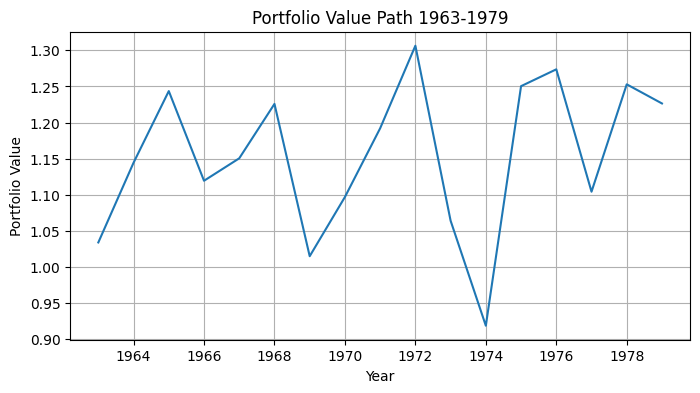

In [ ]:
# testing the model, looks back for two years then predicts for next two years
import matplotlib.pyplot as plt
result = run_annual_policy(env, ipm, actor, assets, permno_to_name,
                      exploration_noise=0.0, top_k=10)

annual_performance_data = []
for decision_date in result.decision_date.unique():
    # All rows for a given decision_date will have the same annual_return, ann_vol, ann_sharpe
    # We can just take the first one (or any) for that date.
    metrics = result[result['decision_date'] == decision_date].iloc[0]
    annual_performance_data.append({
        'year': decision_date.year,
        'annual_return': metrics['annual_return'],
        'annual_volatility': metrics['ann_vol'],
        'annual_sharpe': metrics['ann_sharpe']
    })

annual_performance_df = pd.DataFrame(annual_performance_data)
display(annual_performance_df)
plt.figure(figsize=(8,4))
plt.plot(annual_performance_df["year"], np.cumprod(1 + annual_performance_df["annual_return"]))
plt.title(f"Portfolio Value Path 1963-1979")
plt.ylabel("Portfolio Value")
plt.xlabel("Year")
plt.grid(True)
plt.show()



In [ ]:
# save the parameters
# actor.save_weights("actor_30.weights.h5")
# critic.save_weights("critic_30.weights.h5")
# ipm.save_weights("ipm_30.weights.h5")

#Loading parameters
actor.load_weights("/content/actor_30.weights.h5")
critic.load_weights("/content/critic_30.weights.h5")
ipm.load_weights("/content/ipm_30.weights.h5")

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = '/content/actor_30.weights.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [ ]:
dates_idx = pd.DatetimeIndex(pd.to_datetime(dates) + pd.offsets.MonthEnd(0))
date_to_t = {d: i for i, d in enumerate(dates_idx)}

In [ ]:
monthly_rows = []

for decision_date in result.decision_date.unique():
    d = pd.to_datetime(decision_date) + pd.offsets.MonthEnd(0)
    t_jan = date_to_t[d]

    # rebuild weights from result (top_k only, simple)
    rows = result[result["decision_date"] == decision_date]
    w = np.zeros(len(assets) + 1)
    w[0] = rows["cash_weight"].iloc[0]

    for _, r in rows.iterrows():
        j = np.where(assets == r["permno"])[0][0]
        w[1 + j] = r["weight"]

    w = w / w.sum()
    w_stocks = w[1:]

    # monthly portfolio returns (Jan → Dec)
    rel_12 = close_mat[t_jan : t_jan + 12]   # price ratios
    port_monthly_ret = (rel_12 - 1.0) @ w_stocks

    for month, r in zip(dates_idx[t_jan:t_jan+12], port_monthly_ret):
        monthly_rows.append({
            "year": decision_date.year,
            "month": month,
            "portfolio_monthly_return": r
        })


In [ ]:
monthly_returns_df = pd.DataFrame(monthly_rows)
display(monthly_returns_df)


,year,month,portfolio_monthly_return
0,1963,1963-01-31,-0.023828
1,1963,1963-02-28,-0.022627
2,1963,1963-03-31,0.022963
3,1963,1963-04-30,0.041716
4,1963,1963-05-31,0.023483
...,...,...,...
199,1979,1979-08-31,0.044725
200,1979,1979-09-30,-0.028523
201,1979,1979-10-31,-0.069978
202,1979,1979-11-30,0.025945


In [ ]:
# import matplotlib.pyplot as plt

# for y in monthly_returns_df["year"].unique():
#     df_y = monthly_returns_df[monthly_returns_df["year"] == y]

#     plt.figure(figsize=(8,4))
#     plt.plot(df_y["month"], np.cumprod(1 + df_y["portfolio_monthly_return"]))
#     plt.title(f"Portfolio Value Path – {y}")
#     plt.ylabel("Portfolio Value")
#     plt.xlabel("Month")
#     plt.grid(True)
#     plt.show()


# Using Validation Data: to validate the parameters

In [ ]:
import pandas as pd
df_companies_1981_2000 = pd.read_csv('/content/drive/MyDrive/Senior Year Projects/Thesis/Data/DRL_data/drl_companies_1981_2000.csv')
df_1981_2000= pd.read_csv('/content/drive/MyDrive/Senior Year Projects/Thesis/Data/DRL_data/drl_1981_2000.csv')

In [ ]:
import pandas as pd
# fix the misalignment
df_2 = df_companies_1981_2000.copy()
df_3 = df_1981_2000.copy()
df_2["date"] = pd.to_datetime(df_2["date"])
df_3 ["date"] = pd.to_datetime(df_3 ["date"]) # Convert df_1['date'] to datetime
df_2 = df_2.sort_values(["date", "permno"])
df_2["month"] = df_2["date"].dt.to_period("M")
df_3 ["month"]  = (df_3 ["date"] - pd.offsets.MonthBegin(1)).dt.to_period("M")

merged_1 = df_2.merge(
    df_3 [["month", "price_ratio"]], # Correct column name from 'sp500_price_ratio' to 'price_ratio'
    on="month",
    how="left"
)

In [ ]:
import numpy as np
import pandas as pd

# Use the merged dataframe for consistency
# The merged dataframe already has 'date' as datetime and 'price_ratio' aligned by month
assets_val = np.array(sorted(merged_1["permno"].unique()))
dates_val  = np.array(sorted(merged_1["date"].unique())) # These dates are from df_companies_1960_1980
m = len(assets_val)

def pivot(col):
    mat = (merged_1.pivot(index="date", columns="permno", values=col)
             .loc[dates_val, assets_val]
             .fillna(0) # Fill NaN values with 0
             .to_numpy(dtype=np.float32))
    return mat

open_mat_1  = pivot("open_price")
high_mat_1  = pivot("high_price")
low_mat_1   = pivot("low_price")
close_mat_1 = pivot("close_ratio")

# SP500 ratio series aligned to dates (one value per month)
# Since `merged` already contains `price_ratio` correctly aligned with `dates` (from company data),
# we can simply extract it from `merged` grouped by `date`.
sp500_1 = (merged_1.groupby("date")["price_ratio"].first().loc[dates_val].to_numpy(dtype=np.float32))

In [ ]:
W = 24
t = W
x_seq_1 = np.concatenate(
    [open_mat_1[t-W:t], high_mat_1[t-W:t], low_mat_1[t-W:t], close_mat_1[t-W:t]],
    axis=1
)
mu_t_1 = ipm(x_seq_1[None, ...]).numpy().squeeze()


print("IPM output shape:", mu_t_1.shape)

# Previous weights
w_prev_1 = np.zeros(m + 1, dtype=np.float32)
w_prev_1[0] = 1.0

# Actor state
state_t_1 = np.concatenate([mu_t_1, w_prev_1, [sp500_1[t]]], axis=0)
print("State shape:", state_t_1.shape)

# Actor decision
w_t_1 = actor(state_t_1[None, ...]).numpy().squeeze()
print("Action sum:", w_t_1.sum(), "min weight:", w_t_1.min())

# Critic eval
q_val = critic(state_t_1[None, ...], w_t_1[None, ...]).numpy()
print("Q value:", q_val)

# Permno to name
permno_to_name_val = (
    df_2[["permno","company_name"]]
    .drop_duplicates()
    .set_index("permno")["company_name"]
    .to_dict()
)
# # Target layers
# actor_target = ActorHead(n_assets=m+1) # Assuming m is defined earlier
# critic_target = CriticHead()

# # Calculate state and action dimensions for dummy calls
# state_dim = 4*m + (m+1) + 1 # IPM output (D_ipm), previous weights (m+1), SP500 ratio (1)
# action_dim = m+1 # Portfolio weights (m+1)

# Build target network weights by calling them with dummy inputs
# actor_target(tf.zeros((1, state_dim), dtype=tf.float32), training=False)
# critic_target(tf.zeros((1, state_dim), dtype=tf.float32), tf.zeros((1, action_dim), dtype=tf.float32), training=False)

# Initialize target networks with actor/critic weights (or random for now, will be soft-updated)
# actor_target.set_weights(actor.get_weights())
# critic_target.set_weights(critic.get_weights())

# # Instantiate optimizers (assuming they are not globally defined)
# actor_opt = tf.keras.optimizers.Adam(learning_rate=1e-4)
# critic_opt = tf.keras.optimizers.Adam(learning_rate=1e-3)


IPM output shape: (184,)
State shape: (232,)
Action sum: 1.0000001 min weight: 0.013680662
Q value: [[0.09841404]]


,year,annual_return,annual_volatility,annual_sharpe
0,1983,0.022329,0.093158,0.279411
1,1984,0.072228,0.127733,0.605259
2,1985,0.125661,0.120821,1.038900
3,1986,0.183332,0.227118,0.848998
4,1987,-0.156446,0.224058,-0.641586
5,1988,0.125047,0.097347,1.260423
6,1989,0.077928,0.136853,0.612589
7,1990,0.052799,0.167008,0.386702
8,1991,0.133701,0.130441,1.025827
9,1992,0.023088,0.092465,0.289373


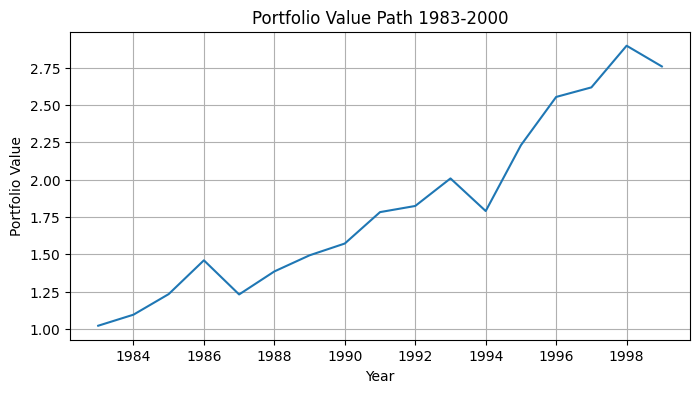

Cumulative annual return: 0.06149439195489159
Cumulative annual volatility: 0.135988445363622
Cumulative annual sharpe: 0.4874068576802727


In [ ]:
import matplotlib.pyplot as plt
# Build the feature matrix for validation data
X_val = build_feature_matrix(open_mat=open_mat_1, high_mat=high_mat_1, low_mat=low_mat_1, close_mat=close_mat_1)

# Build the environment
env_val = AnnualJanuaryEnv(
    dates=dates_val,
    X=X_val,
    close_mat=close_mat_1,
    sp500=sp500_1,              # optional
    lookback=24,
    hold_months=12,
    tc=0.001,
    reward_weights=(1.0, 0.5, 0.1)  # tune α⋅annual_return+β⋅Sharpe−γ⋅vol
)
# run the model
result_val = run_annual_policy(env_val, ipm, actor, assets_val, permno_to_name_val, exploration_noise=0.0, top_k=10)
# Graoh the results
annual_performance_data_val = []
for decision_date in result_val.decision_date.unique():
    # All rows for a given decision_date will have the same annual_return, ann_vol, ann_sharpe
    # We can just take the first one (or any) for that date.
    metrics = result_val[result_val['decision_date'] == decision_date].iloc[0]
    annual_performance_data_val.append({
        'year': decision_date.year,
        'annual_return': metrics['annual_return'],
        'annual_volatility': metrics['ann_vol'],
        'annual_sharpe': metrics['ann_sharpe']
    })

annual_performance_df_val = pd.DataFrame(annual_performance_data_val)
display(annual_performance_df_val)
plt.figure(figsize=(8,4))
plt.plot(annual_performance_df_val["year"], np.cumprod(1 + annual_performance_df_val["annual_return"]))
plt.title(f"Portfolio Value Path 1983-2000")
plt.ylabel("Portfolio Value")
plt.xlabel("Year")
plt.grid(True)
plt.show()

## Collect Cumulative annual returns, sharpe and volatility per period
## cumulative annual return
R = annual_performance_df_val["annual_return"].to_numpy()
T = len(R)
cumulative_annual_return =np.prod((1+R) ** (1 / T)) - 1
print(f"Cumulative annual return: {cumulative_annual_return}")
## cumulative annual volatility
S = annual_performance_df_val["annual_volatility"].to_numpy()
cumulative_annual_volatility = np.sqrt(np.mean(S ** 2))
print(f"Cumulative annual volatility: {cumulative_annual_volatility}")
## cumulative annual sharpe
sharpe = annual_performance_df_val["annual_sharpe"].to_numpy()
cumulative_annual_sharpe = np.mean(R) / cumulative_annual_volatility
print(f"Cumulative annual sharpe: {cumulative_annual_sharpe}")





# Automated Parameter Finetuning

In [ ]:
# This part finetunes the parameters automatically
!pip -q install -U keras-tuner


In [ ]:
import keras_tuner as kt
import tensorflow as tf
import numpy as np

In [ ]:
def evaluate_on_val(val_env, ipm, actor, top_k=10):
    val_result = run_annual_policy(
        val_env, ipm, actor,
        val_env.assets, val_env.permno_to_name,
        exploration_noise=0.0, top_k=top_k
    )
    val_yearly = (
        val_result.sort_values(["decision_date","rank"])
                  .groupby("decision_date", as_index=False)
                  .first()[["annual_return","ann_vol","ann_sharpe"]]
    )
    return float(val_yearly["ann_sharpe"].mean())

In [ ]:
class RLHyperModel(kt.HyperModel):
    def __init__(self, m):
        self.m = m
        self.state_dim = 4*m + (m+1) + 1
        self.action_dim = m+1

    def build(self, hp):
        ipm = LSTM_IPM(D=4*self.m)
        actor = ActorHead(n_assets=self.m+1)
        critic = CriticHead()

        container = tf.keras.Model()
        container.ipm = ipm
        container.actor = actor
        container.critic = critic
        return container

In [ ]:
class RLTuner(kt.RandomSearch):

    def run_trial(self, trial, train_env, val_env):
        hp = trial.hyperparameters

        # ---- Tuned hyperparameters ----
        actor_lr = hp.Float("actor_lr", 5e-5, 6.25e-5, sampling="log")
        critic_lr = hp.Float("critic_lr", 5e-4, 6.25e-4, sampling="log")
        tau = hp.Float("tau", 1e-3, 1e-2, sampling="log")
        gamma = hp.Float("gamma", 0.90, 0.999)
        policy_delay = hp.Int("policy_delay", 1, 4)
        exploration_noise = hp.Float("exploration_noise", 0.0, 0.4)
        batch_size = hp.Choice("batch_size", [16, 32, 46, 64])
        warmup = hp.Choice("warmup", [50, 100, 200])
        episodes = hp.Choice("episodes", [10, 15, 20, 30, 50])

        tf.keras.backend.clear_session()

        container = self.hypermodel.build(hp)
        ipm = container.ipm
        actor = container.actor
        critic = container.critic

        # ---- Targets ----
        actor_target = ActorHead(n_assets=self.hypermodel.m+1)
        critic_target = CriticHead()

        state_dim = self.hypermodel.state_dim
        action_dim = self.hypermodel.action_dim

        # Build models
        _ = actor(tf.zeros((1, state_dim)))
        _ = actor_target(tf.zeros((1, state_dim)))
        _ = critic(tf.zeros((1, state_dim)),
                   tf.zeros((1, action_dim)))
        _ = critic_target(tf.zeros((1, state_dim)),
                          tf.zeros((1, action_dim)))

        actor_target.set_weights(actor.get_weights())
        critic_target.set_weights(critic.get_weights())

        actor_opt = tf.keras.optimizers.Adam(actor_lr)
        critic_opt = tf.keras.optimizers.Adam(critic_lr)

        actor_opt.build(actor.trainable_variables)
        critic_opt.build(critic.trainable_variables)

        # Wrap ni_train_step with tuned params
        def ni_step(actor_, critic_, actor_t_, critic_t_, actor_opt_, critic_opt_, batch_):
            return ni_train_step(
                actor_, critic_, actor_t_, critic_t_,
                actor_opt_, critic_opt_, batch_,
                gamma=gamma, tau=tau, policy_delay=policy_delay
            )

        # ---- TRAIN ----
        train_annual(
            train_env, ipm, actor, critic, actor_target, critic_target,
            ni_step, actor_opt, critic_opt,
            episodes=episodes,
            batch_size=batch_size,
            warmup=warmup,
            exploration_noise=exploration_noise
        )

        # ---- VALIDATE ----
        val_result = run_annual_policy(
            val_env, ipm, actor,
            globals()['assets_val'], globals()['permno_to_name_val'],
            exploration_noise=0.0,
            top_k=10
        )

        val_yearly = (
            val_result.sort_values(["decision_date","rank"])
                      .groupby("decision_date", as_index=False)
                      .first()[["ann_sharpe"]]
        )

        val_sharpe = float(val_yearly["ann_sharpe"].mean())

        self.oracle.update_trial(trial.trial_id,
                                 {"val_sharpe": val_sharpe})


In [ ]:
hypermodel = RLHyperModel(m=m)

tuner = RLTuner(
    hypermodel=hypermodel,
    objective=kt.Objective("val_sharpe", direction="max"),
    max_trials=10,
    directory="rl_tuning",
    project_name="annual_rl",
    overwrite=True
)

tuner.search(train_env=env, val_env=env_val)

best_hp = tuner.get_best_hyperparameters(1)[0]
print("Best hyperparameters:", best_hp.values)

Trial 4 Complete [00h 04m 24s]
val_sharpe: 0.6269556736002199

Best val_sharpe So Far: 0.6867585894935719
Total elapsed time: 00h 09m 20s

Search: Running Trial #5

Value             |Best Value So Far |Hyperparameter
5.2898e-05        |5e-05             |actor_lr
0.0006244         |0.0005            |critic_lr
0.001843          |0.001             |tau
0.90409           |0.9               |gamma
4                 |1                 |policy_delay
0.35363           |0                 |exploration_noise
32                |16                |batch_size
50                |50                |warmup
50                |10                |episodes

episode 1/50 | avg step reward=0.0888 | last-year sharpe=0.532
episode 2/50 | avg step reward=0.0745 | last-year sharpe=0.569
episode 3/50 | avg step reward=0.1682 | last-year sharpe=0.414
episode 4/50 | avg step reward=0.1064 | last-year sharpe=-0.035
episode 5/50 | avg step reward=0.1302 | last-year sharpe=-0.413
episode 6/50 | avg step reward=0.17

KeyboardInterrupt: 

In [ ]:
# re-running the model
# read out best values
# actor_lr = best_hp.get("actor_lr")
# critic_lr = best_hp.get("critic_lr")
# tau = best_hp.get("tau")
# gamma = best_hp.get("gamma")
# policy_delay = best_hp.get("policy_delay")
# batch_size = best_hp.get("batch_size")
# warmup = best_hp.get("warmup")
actor_lr = 5.0712933704394026e-05
critic_lr = 0.000565422166370897
tau = 0.006613662750284627
gamma = 0.964388334157933
policy_delay = 3
batch_size = 32
warmup = 50

# rebuild fresh models
ipm = LSTM_IPM(D=4*m)
actor = ActorHead(n_assets=m+1)
critic = CriticHead()

actor_target = ActorHead(n_assets=m+1)
critic_target = CriticHead()

In [ ]:
state_dim  = 4*m + (m+1) + 1
action_dim = m+1

_ = actor(tf.zeros((1, state_dim), tf.float32))
_ = actor_target(tf.zeros((1, state_dim), tf.float32))

_ = critic(tf.zeros((1, state_dim), tf.float32),
           tf.zeros((1, action_dim), tf.float32))
_ = critic_target(tf.zeros((1, state_dim), tf.float32),
                  tf.zeros((1, action_dim), tf.float32))

actor_target.set_weights(actor.get_weights())
critic_target.set_weights(critic.get_weights())

In [ ]:
actor_opt = tf.keras.optimizers.Adam(actor_lr)
critic_opt = tf.keras.optimizers.Adam(critic_lr)

actor_opt.build(actor.trainable_variables)
critic_opt.build(critic.trainable_variables)

In [ ]:
def ni_step(actor, critic, actor_target, critic_target, actor_opt, critic_opt, batch):
    return ni_train_step(
        actor, critic, actor_target, critic_target,
        actor_opt, critic_opt, batch,
        gamma=gamma,
        tau=tau,
        policy_delay=policy_delay
    )

In [ ]:
train_annual(
    env, ipm, actor, critic, actor_target, critic_target,
    ni_step, actor_opt, critic_opt,
    episodes=25,
    batch_size=batch_size,
    warmup=warmup,
    exploration_noise=0.02     # training noise (not test)
)

episode 1/25 | avg step reward=0.0467 | last-year sharpe=0.103
episode 2/25 | avg step reward=0.1170 | last-year sharpe=-0.144
episode 3/25 | avg step reward=0.0743 | last-year sharpe=-0.166
episode 4/25 | avg step reward=0.0898 | last-year sharpe=-0.364
episode 5/25 | avg step reward=0.0971 | last-year sharpe=-0.247
episode 6/25 | avg step reward=0.1180 | last-year sharpe=-0.046
episode 7/25 | avg step reward=0.0916 | last-year sharpe=0.160
episode 8/25 | avg step reward=0.1056 | last-year sharpe=0.292
episode 9/25 | avg step reward=0.0743 | last-year sharpe=-0.369
episode 10/25 | avg step reward=0.1254 | last-year sharpe=-0.010
episode 11/25 | avg step reward=0.2073 | last-year sharpe=0.290
episode 12/25 | avg step reward=0.1619 | last-year sharpe=-0.162
episode 13/25 | avg step reward=0.0949 | last-year sharpe=0.226
episode 14/25 | avg step reward=0.0724 | last-year sharpe=-0.130
episode 15/25 | avg step reward=0.1085 | last-year sharpe=-0.014
episode 16/25 | avg step reward=0.0944 

,year,annual_return,annual_volatility,annual_sharpe
0,1983,0.027103,0.093952,0.327465
1,1984,0.060597,0.135377,0.496987
2,1985,0.129696,0.118728,1.085713
3,1986,0.194590,0.227173,0.891220
4,1987,-0.145455,0.228904,-0.567180
5,1988,0.115518,0.099112,1.153047
6,1989,0.056231,0.132332,0.474868
7,1990,0.055564,0.169422,0.398833
8,1991,0.138314,0.136331,1.016521
9,1992,0.029833,0.106724,0.324907


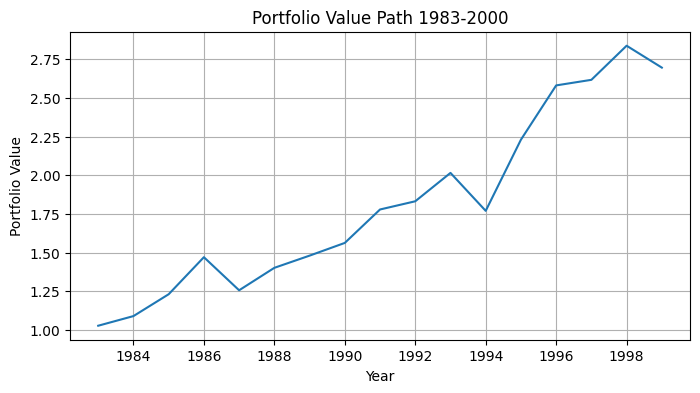

Cumulative annual return: 0.06006592254989296
Cumulative annual volatility: 0.1378931546240925
Cumulative annual sharpe: 0.4718326665040367


In [ ]:
# run the model
result_val = run_annual_policy(
    env_val, ipm, actor,
    assets_val, permno_to_name_val, # Use global variables
    exploration_noise=0.0,
    top_k=10
)
# Graoh the results
annual_performance_data_val = []
for decision_date in result_val.decision_date.unique():
    # All rows for a given decision_date will have the same annual_return, ann_vol, ann_sharpe
    # We can just take the first one (or any) for that date.
    metrics = result_val[result_val['decision_date'] == decision_date].iloc[0]
    annual_performance_data_val.append({
        'year': decision_date.year,
        'annual_return': metrics['annual_return'],
        'annual_volatility': metrics['ann_vol'],
        'annual_sharpe': metrics['ann_sharpe']
    })

annual_performance_df_val = pd.DataFrame(annual_performance_data_val)
display(annual_performance_df_val)
plt.figure(figsize=(8,4))
plt.plot(annual_performance_df_val["year"], np.cumprod(1 + annual_performance_df_val["annual_return"]))
plt.title(f"Portfolio Value Path 1983-2000")
plt.ylabel("Portfolio Value")
plt.xlabel("Year")
plt.grid(True)
plt.show()

## Collect Cumulative annual returns, sharpe and volatility per period
## cumulative annual return
R = annual_performance_df_val["annual_return"].to_numpy()
T = len(R)
cumulative_annual_return =np.prod((1+R) ** (1 / T)) - 1
print(f"Cumulative annual return: {cumulative_annual_return}")
## cumulative annual volatility
S = annual_performance_df_val["annual_volatility"].to_numpy()
cumulative_annual_volatility = np.sqrt(np.mean(S ** 2))
print(f"Cumulative annual volatility: {cumulative_annual_volatility}")
## cumulative annual sharpe
sharpe = annual_performance_df_val["annual_sharpe"].to_numpy()
cumulative_annual_sharpe = np.mean(R) / cumulative_annual_volatility
print(f"Cumulative annual sharpe: {cumulative_annual_sharpe}")

In [ ]:
display(result_val)

,decision_date,rank,permno,company,weight,cash_weight,annual_return,ann_vol,ann_sharpe,reward
0,1983-01-31,1,22509,P P G INDUSTRIES INC,0.061744,0.011557,0.013629,0.103987,0.177337,0.090910
1,1983-01-31,2,17830,UNITED TECHNOLOGIES CORP,0.058345,0.011557,0.013629,0.103987,0.177337,0.090910
2,1983-01-31,3,22592,MINNESOTA MINING & MFG CO,0.057743,0.011557,0.013629,0.103987,0.177337,0.090910
3,1983-01-31,4,17005,C V S CORP,0.034595,0.011557,0.013629,0.103987,0.177337,0.090910
4,1983-01-31,5,13928,PHILLIPS PETROLEUM CO,0.033967,0.011557,0.013629,0.103987,0.177337,0.090910
...,...,...,...,...,...,...,...,...,...,...
165,1999-01-31,6,24109,AMERICAN ELECTRIC POWER CO INC,0.040821,0.005888,-0.057699,0.177645,-0.253705,-0.202513
166,1999-01-31,7,13928,PHILLIPS PETROLEUM CO,0.034264,0.005888,-0.057699,0.177645,-0.253705,-0.202513
167,1999-01-31,8,17005,C V S CORP,0.028288,0.005888,-0.057699,0.177645,-0.253705,-0.202513
168,1999-01-31,9,11674,D T E ENERGY CO,0.024990,0.005888,-0.057699,0.177645,-0.253705,-0.202513


# Using Test Data

In [ ]:
# load test data
import pandas as pd
df_companies_2001_2024 = pd.read_csv('/content/drive/MyDrive/Senior Year Projects/Thesis/Data/DRL_data/drl_companies_2001_2024.csv')
df_2001_2024= pd.read_csv('/content/drive/MyDrive/Senior Year Projects/Thesis/Data/DRL_data/drl_2001_2024.csv')

In [ ]:
import pandas as pd
# fix the misalignment
df_companies_test = df_companies_2001_2024.copy()
df_test = df_2001_2024.copy()
df_companies_test["date"] = pd.to_datetime(df_companies_test["date"])
df_test ["date"] = pd.to_datetime(df_test ["date"]) # Convert df_1['date'] to datetime
df_companies_test = df_companies_test.sort_values(["date", "permno"])
df_companies_test["month"] = df_companies_test["date"].dt.to_period("M")
df_test ["month"]  = (df_test ["date"] - pd.offsets.MonthBegin(1)).dt.to_period("M")

merged_test = df_companies_test.merge(
    df_test [["month", "price_ratio"]], # Correct column name from 'sp500_price_ratio' to 'price_ratio'
    on="month",
    how="left"
)

In [ ]:
import numpy as np
import pandas as pd

# Use the merged dataframe for consistency
# The merged dataframe already has 'date' as datetime and 'price_ratio' aligned by month
assets_test = np.array(sorted(merged_test["permno"].unique()))
dates_test  = np.array(sorted(merged_test["date"].unique())) # These dates are from df_companies_2001_2024
m_test = len(assets_test)

def pivot(col):
    mat = (merged_test.pivot(index="date", columns="permno", values=col)
             .loc[dates_test, assets_test]
             .fillna(0) # Fill NaN values with 0
             .to_numpy(dtype=np.float32))
    return mat

open_mat_test  = pivot("open_price")
high_mat_test  = pivot("high_price")
low_mat_test   = pivot("low_price")
close_mat_test = pivot("close_ratio")

# SP500 ratio series aligned to dates (one value per month)
# Since `merged` already contains `price_ratio` correctly aligned with `dates` (from company data),
# we can simply extract it from `merged` grouped by `date`.
sp500_test = (merged_test.groupby("date")["price_ratio"].first().loc[dates_test].to_numpy(dtype=np.float32))

## debugging
print(len(sp500_test))

288


In [ ]:
W = 24
t = W
x_seq_test = np.concatenate(
    [open_mat_test[t-W:t], high_mat_test[t-W:t], low_mat_test[t-W:t], close_mat_test[t-W:t]],
    axis=1
)
mu_t_test = ipm(x_seq_test[None, ...]).numpy().squeeze()


print("IPM output shape:", mu_t_test.shape)

# Previous weights
w_prev_test = np.zeros(m_test + 1, dtype=np.float32)
w_prev_test[0] = 1.0

# Actor state
state_t_test = np.concatenate([mu_t_test, w_prev_test, [sp500_test[t]]], axis=0)
print("State shape:", state_t_test.shape)

# Actor decision
w_t_test = actor(state_t_test[None, ...]).numpy().squeeze()
print("Action sum:", w_t_test.sum(), "min weight:", w_t_test.min())

# Critic eval
q_test = critic(state_t_test[None, ...], w_t_test[None, ...]).numpy()
print("Q value:", q_test)

# Permno to name
permno_to_name_test = (
    df_companies_test[["permno","company_name"]]
    .drop_duplicates()
    .set_index("permno")["company_name"]
    .to_dict()
)

IPM output shape: (184,)
State shape: (232,)
Action sum: 1.0 min weight: 0.012222299
Q value: [[0.06259277]]


,year,annual_return,annual_volatility,annual_sharpe
0,2003,0.354949,0.104499,2.990275
1,2004,0.030446,0.066686,0.480471
2,2005,0.041710,0.083547,0.528360
3,2006,0.104706,0.042658,2.363476
4,2007,0.028057,0.113073,0.297194
5,2008,-0.347210,0.187282,-2.145631
6,2009,0.332500,0.220594,1.420188
7,2010,0.290728,0.177789,1.532095
8,2011,0.029148,0.134305,0.274713
9,2012,0.094363,0.084839,1.106072


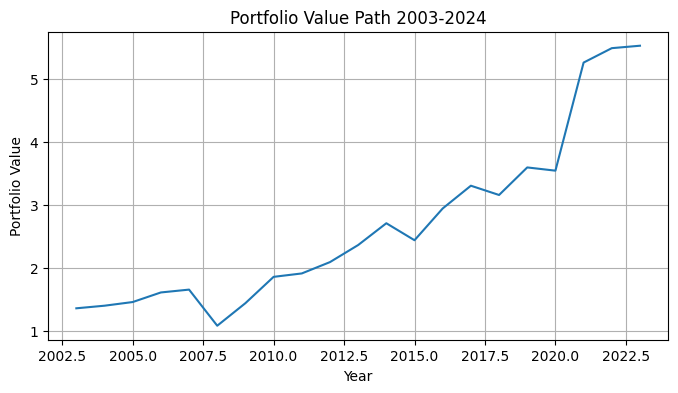

Cumulative annual return: 0.08480043251636404
Cumulative annual volatility: 0.13951376315742758
Cumulative annual sharpe: 0.7104175806742271


In [ ]:
import matplotlib.pyplot as plt
# Build the feature matrix for validation data
X_test = build_feature_matrix(open_mat=open_mat_test, high_mat=high_mat_test, low_mat=low_mat_test, close_mat=close_mat_test)

# Build the environment
env_test = AnnualJanuaryEnv(
    dates=dates_test,
    X=X_test,
    close_mat=close_mat_test,
    sp500=sp500_test,              # optional
    lookback=24,
    hold_months=12,
    tc=0.001,
    reward_weights=(1.0, 0.5, 0.1)  # tune α⋅annual_return+β⋅Sharpe−γ⋅vol
)
# run the model
result_test = run_annual_policy(env_test, ipm, actor, assets_test, permno_to_name_test, exploration_noise=0.0, top_k=10)
# Graoh the results
annual_performance_data_test = []
for decision_date in result_test.decision_date.unique():
    # All rows for a given decision_date will have the same annual_return, ann_vol, ann_sharpe
    # We can just take the first one (or any) for that date.
    metrics = result_test[result_test['decision_date'] == decision_date].iloc[0]
    annual_performance_data_test.append({
        'year': decision_date.year,
        'annual_return': metrics['annual_return'],
        'annual_volatility': metrics['ann_vol'],
        'annual_sharpe': metrics['ann_sharpe']
    })

annual_performance_df_test = pd.DataFrame(annual_performance_data_test)
display(annual_performance_df_test)
plt.figure(figsize=(8,4))
plt.plot(annual_performance_df_test["year"], np.cumprod(1 + annual_performance_df_test["annual_return"]))
plt.title(f"Portfolio Value Path 2003-2024")
plt.ylabel("Portfolio Value")
plt.xlabel("Year")
plt.grid(True)
plt.show()

## Collect Cumulative annual returns, sharpe and volatility per period
## cumulative annual return
R_test = annual_performance_df_test["annual_return"].to_numpy()
T_test = len(R_test)
cumulative_annual_return_test =np.prod((1+R_test) ** (1 / T_test)) - 1
print(f"Cumulative annual return: {cumulative_annual_return_test}")
## cumulative annual volatility
S_test = annual_performance_df_test["annual_volatility"].to_numpy()
cumulative_annual_volatility_test = np.sqrt(np.mean(S_test ** 2))
print(f"Cumulative annual volatility: {cumulative_annual_volatility_test}")
## cumulative annual sharpe
sharpe_test = annual_performance_df_test["annual_sharpe"].to_numpy()
cumulative_annual_sharpe_test = np.mean(R_test) / cumulative_annual_volatility_test
print(f"Cumulative annual sharpe: {cumulative_annual_sharpe_test}")


,year,annual_return,annual_volatility,annual_sharpe
0,2003,0.354949,0.104499,2.990275
1,2004,0.030446,0.066686,0.480471
2,2005,0.041710,0.083547,0.528360
3,2006,0.104706,0.042658,2.363476
4,2007,0.028057,0.113073,0.297194
5,2008,-0.347210,0.187282,-2.145631
6,2009,0.332500,0.220594,1.420188
7,2010,0.290728,0.177789,1.532095
8,2011,0.029148,0.134305,0.274713
9,2012,0.094363,0.084839,1.106072


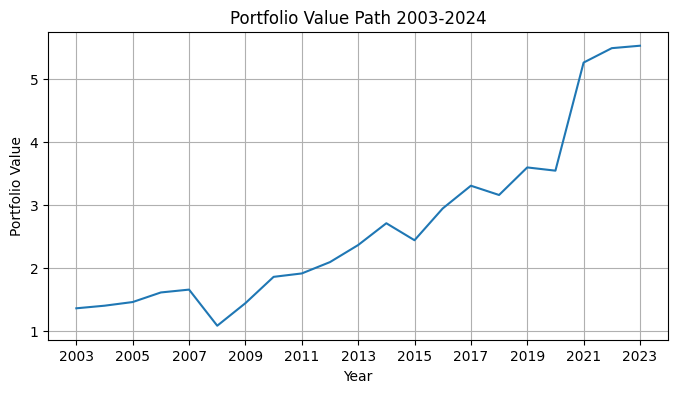

Cumulative annual return: 0.08480043251636404
Cumulative annual volatility: 0.13951376315742758
Cumulative annual sharpe: 0.7104175806742271


In [ ]:
import matplotlib.pyplot as plt
# Proper drawing
display(annual_performance_df_test)
plt.figure(figsize=(8,4))
plt.plot(annual_performance_df_test["year"], np.cumprod(1 + annual_performance_df_test["annual_return"]))
plt.title(f"Portfolio Value Path 2003-2024")
plt.ylabel("Portfolio Value")
plt.xlabel("Year")
plt.xticks(annual_performance_df_test["year"].unique()[::2]) # Set x-axis ticks to whole years with a two-year interval
plt.grid(True)
plt.show()

## Collect Cumulative annual returns, sharpe and volatility per period
## cumulative annual return
R_test = annual_performance_df_test["annual_return"].to_numpy()
T_test = len(R_test)
cumulative_annual_return_test =np.prod((1+R_test) ** (1 / T_test)) - 1
print(f"Cumulative annual return: {cumulative_annual_return_test}")
## cumulative annual volatility
S_test = annual_performance_df_test["annual_volatility"].to_numpy()
cumulative_annual_volatility_test = np.sqrt(np.mean(S_test ** 2))
print(f"Cumulative annual volatility: {cumulative_annual_volatility_test}")
## cumulative annual sharpe
sharpe_test = annual_performance_df_test["annual_sharpe"].to_numpy()
cumulative_annual_sharpe_test = np.mean(R_test) / cumulative_annual_volatility_test
print(f"Cumulative annual sharpe: {cumulative_annual_sharpe_test}")

In [ ]:
display(result_test)

,decision_date,rank,permno,company,weight,cash_weight,annual_return,ann_vol,ann_sharpe,reward
0,2003-01-31,1,18163,PROCTER & GAMBLE CO,0.034278,0.026295,0.354949,0.104499,2.990275,1.838663
1,2003-01-31,2,18542,CATERPILLAR INC,0.032737,0.026295,0.354949,0.104499,2.990275,1.838663
2,2003-01-31,3,12060,GENERAL ELECTRIC CO,0.031576,0.026295,0.354949,0.104499,2.990275,1.838663
3,2003-01-31,4,13901,ALTRIA GROUP INC,0.031393,0.026295,0.354949,0.104499,2.990275,1.838663
4,2003-01-31,5,22509,P P G INDUSTRIES INC,0.030496,0.026295,0.354949,0.104499,2.990275,1.838663
...,...,...,...,...,...,...,...,...,...,...
205,2023-01-31,6,11762,EATON CORP PLC,0.027881,0.020990,0.007064,0.128503,0.113582,0.050873
206,2023-01-31,7,24109,AMERICAN ELECTRIC POWER CO INC,0.027118,0.020990,0.007064,0.128503,0.113582,0.050873
207,2023-01-31,8,18542,CATERPILLAR INC,0.026312,0.020990,0.007064,0.128503,0.113582,0.050873
208,2023-01-31,9,25785,FORD MOTOR CO DEL,0.025911,0.020990,0.007064,0.128503,0.113582,0.050873
